In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import pickle
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn import metrics  


### Reading and Cleaning data

In [87]:
with open ('wdbc.pkl', 'rb') as f:
    data = pickle.load(f)

In [88]:
data.shape

(569, 32)

In [89]:
data.columns

Index(['id', 'malignant', 'radius_0', 'texture_0', 'perimeter_0', 'area_0',
       'smoothness_0', 'compactness_0', 'concavity_0', 'concave points_0',
       'symmetry_0', 'fractal dimension_0', 'radius_1', 'texture_1',
       'perimeter_1', 'area_1', 'smoothness_1', 'compactness_1', 'concavity_1',
       'concave points_1', 'symmetry_1', 'fractal dimension_1', 'radius_2',
       'texture_2', 'perimeter_2', 'area_2', 'smoothness_2', 'compactness_2',
       'concavity_2', 'concave points_2', 'symmetry_2', 'fractal dimension_2'],
      dtype='object')

### EDA

In [90]:
#list of base feature names
features = ['radius', 'texture', 'perimeter', 'area', 'smoothness', 
            'compactness', 'concavity', 'concave points', 'symmetry', 'fractal dimension']

stats_dict = {}
for f in features:
    cols = [col for col in data.columns if col.startswith(f)]
    stats_dict[f] = data[cols].agg(['mean', 'std', 'min', 'max'])

stats_table = pd.concat(stats_dict, axis=1)

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

print(stats_table)

         radius                         texture                       \
       radius_0  radius_1   radius_2  texture_0 texture_1  texture_2   
mean  14.127292  0.405172  16.269190  19.289649  1.216853  25.677223   
std    3.524049  0.277313   4.833242   4.301036  0.551648   6.146258   
min    6.981000  0.111500   7.930000   9.710000  0.360200  12.020000   
max   28.110000  2.873000  36.040000  39.280000  4.885000  49.540000   

       perimeter                                 area  ...   concavity  \
     perimeter_0 perimeter_1 perimeter_2       area_0  ... concavity_2   
mean   91.969033    2.866059  107.261213   654.889104  ...    0.272188   
std    24.298981    2.021855   33.602542   351.914129  ...    0.208624   
min    43.790000    0.757000   50.410000   143.500000  ...    0.000000   
max   188.500000   21.980000  251.200000  2501.000000  ...    1.252000   

       concave points                                     symmetry             \
     concave points_0 concave points_1 co

Text(0.5, 1.0, 'Correlation Heatmap')

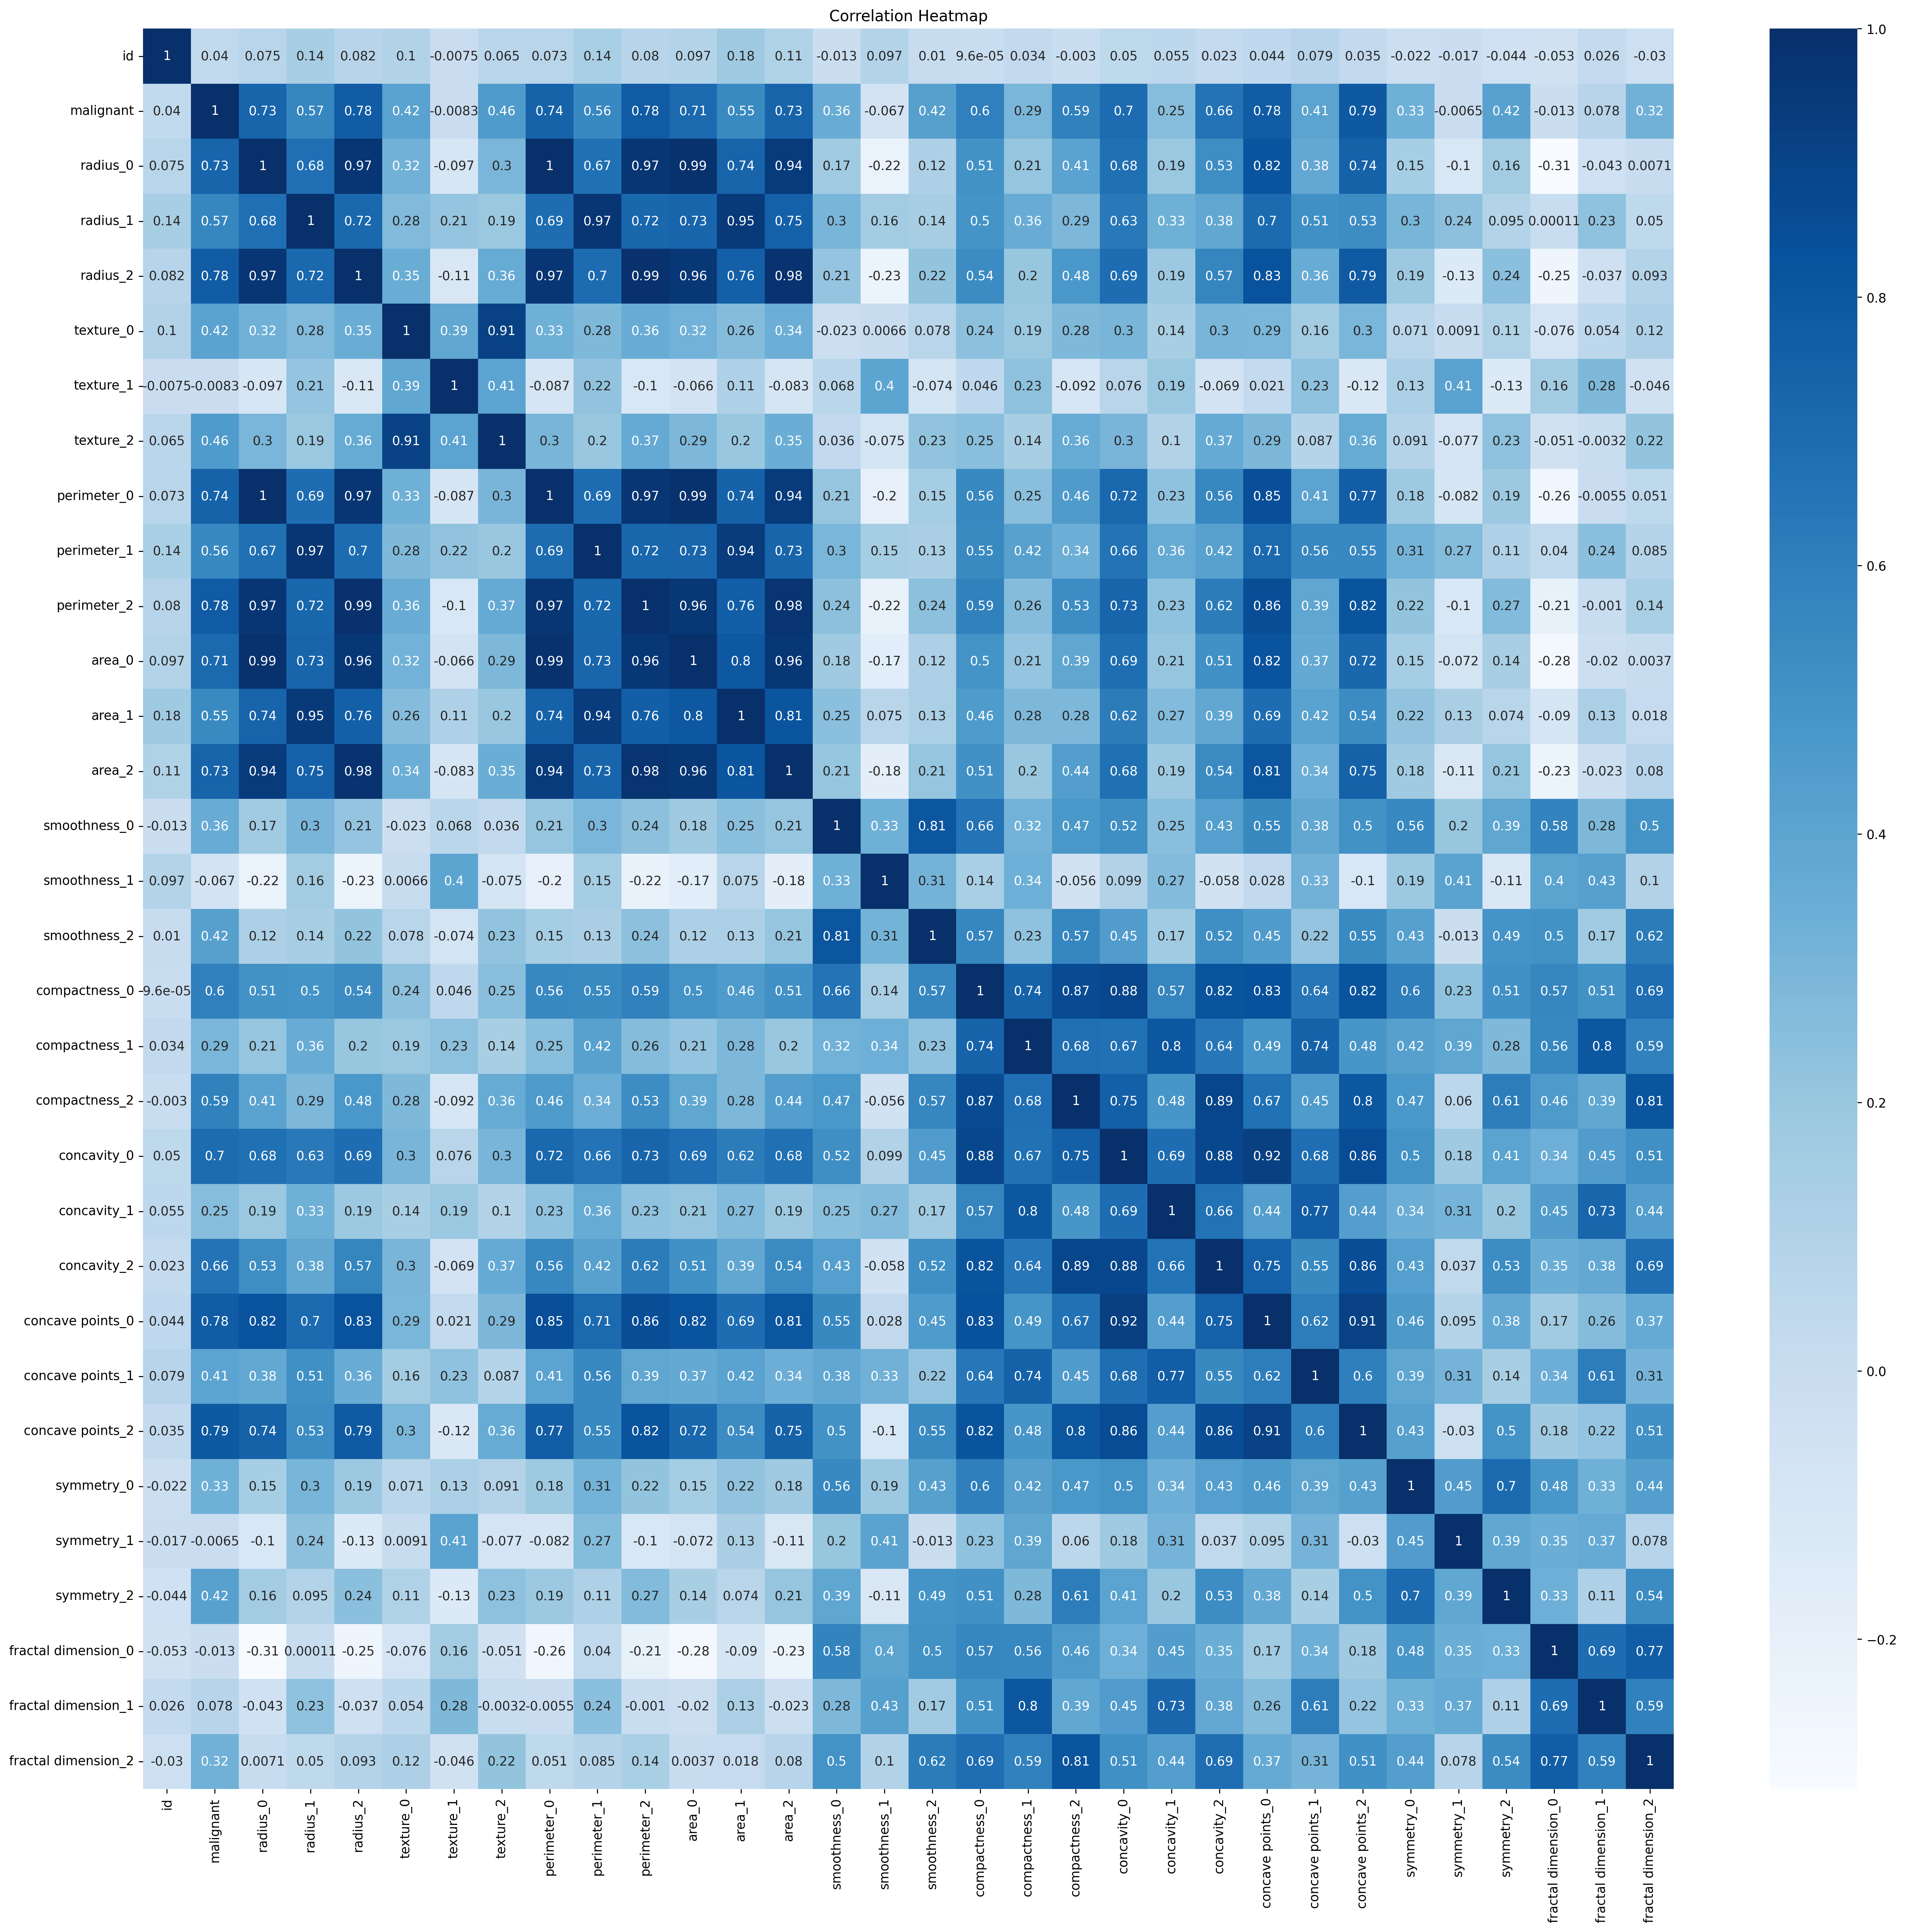

In [91]:
#CORRELATION HEATMAP
new_col_order = [
    'id', 'malignant',
    'radius_0', 'radius_1', 'radius_2',
    'texture_0', 'texture_1', 'texture_2',
    'perimeter_0', 'perimeter_1', 'perimeter_2',
    'area_0', 'area_1', 'area_2',
    'smoothness_0', 'smoothness_1', 'smoothness_2',
    'compactness_0', 'compactness_1', 'compactness_2',
    'concavity_0', 'concavity_1', 'concavity_2',
    'concave points_0', 'concave points_1', 'concave points_2',
    'symmetry_0', 'symmetry_1', 'symmetry_2',
    'fractal dimension_0', 'fractal dimension_1', 'fractal dimension_2'
]

# Reindex the dataframe
new_order_data = data[new_col_order]

corr_matrix = new_order_data.corr()

plt.figure(figsize=(27, 25), dpi = 250)
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
# plt.show()

Sparsity: 0.627


Text(0.5, 1.0, 'Distribution of Malignant Tumors')

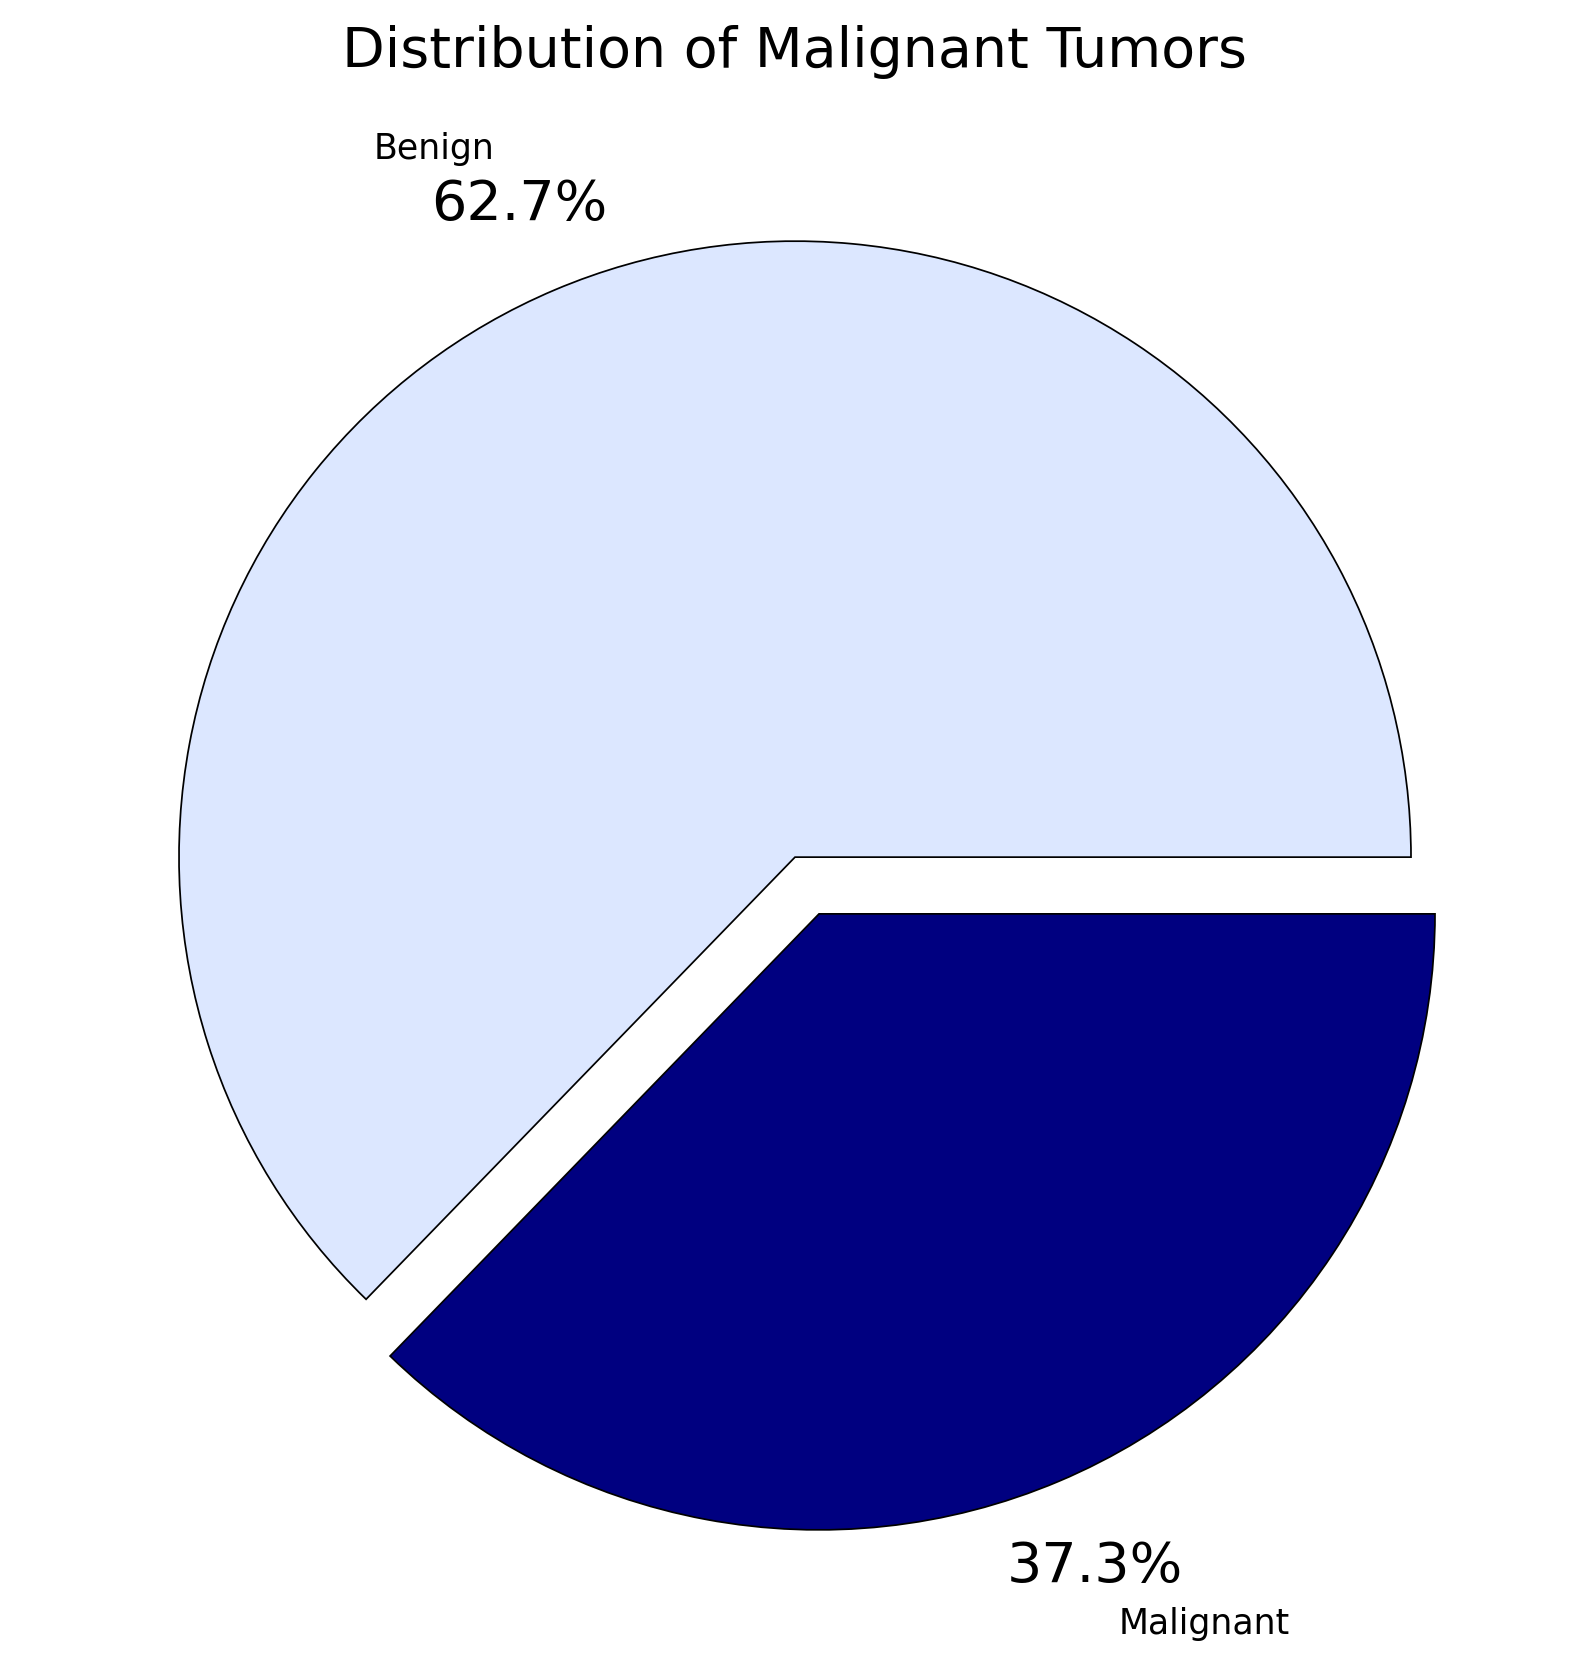

In [92]:
# PIE CHART DISTRIBUTION OF MALIGNANT AND BENIGN TUMORS
distribution = data['malignant'].value_counts()

# Calculate sparsity
total_elements = sum(distribution)
pos = distribution[0]
sparsity = pos / total_elements
print(f"Sparsity: {sparsity:.3f}")

# Plot
labels = ['Benign', 'Malignant']
sizes = [pos, total_elements - pos]

plt.figure(figsize=(8, 8), dpi=250)
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=0,
    colors=['#dce7ff', '#000080'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5},
    explode=[0, 0.1],        # Slightly pull out the small slice
    pctdistance=1.15,         # Move percentage text away from center
    labeldistance=1.25        # Move labels further out
)

for autotext in autotexts:
    autotext.set_fontsize(16)

plt.title('Distribution of Malignant Tumors', fontsize=16)
# plt.show()


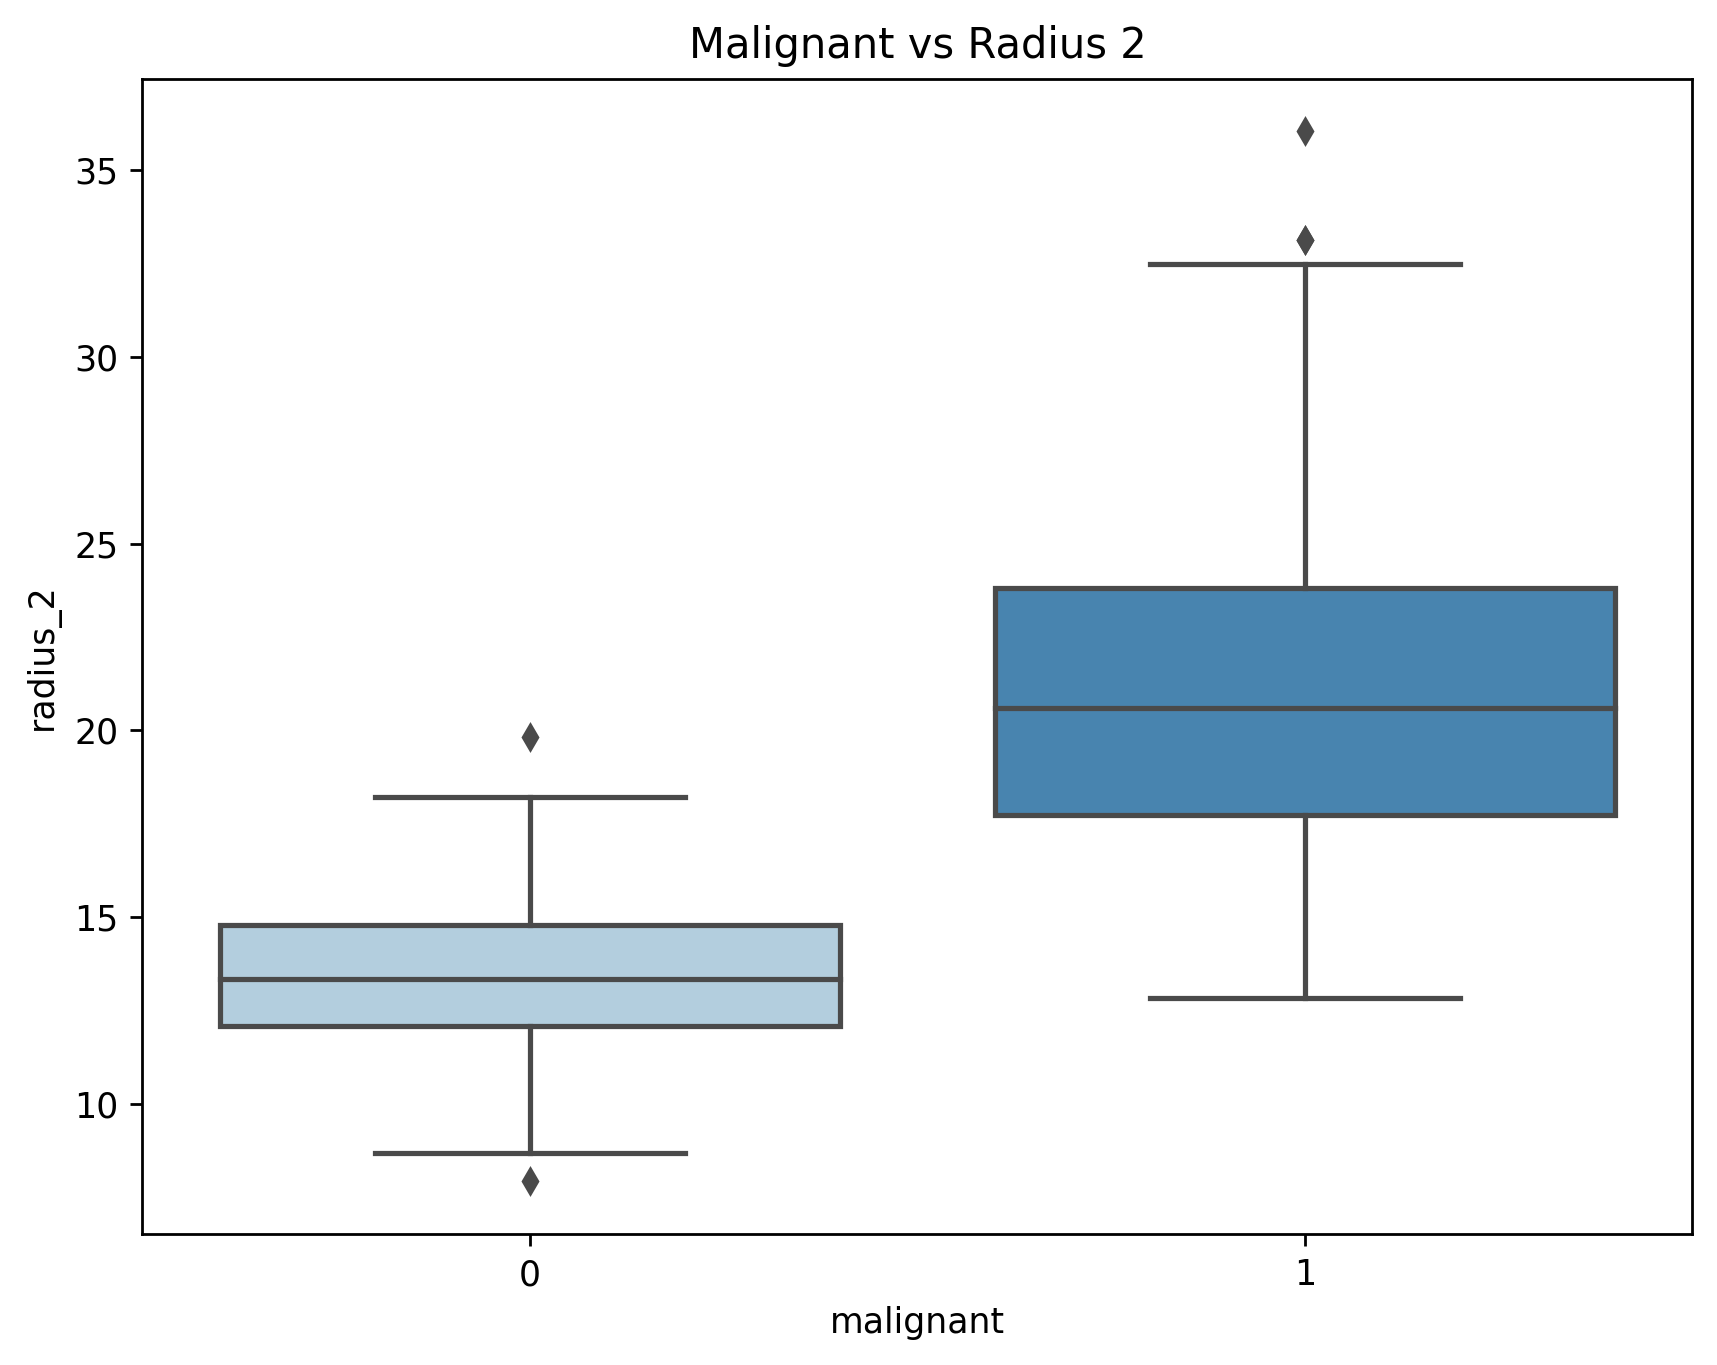

In [93]:
plt.figure(figsize=(8, 6), dpi=250)
sns.boxplot(x='malignant', y='radius_2', data=data, palette='Blues')
plt.title('Malignant vs Radius 2')
plt.show()


### Train Test Split

In [94]:
# X = data.drop('malignant', axis=1)
# y = data['malignant']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

### Rule Based Classifier

ACCURACY OF THE MODEL: 0.6754385964912281


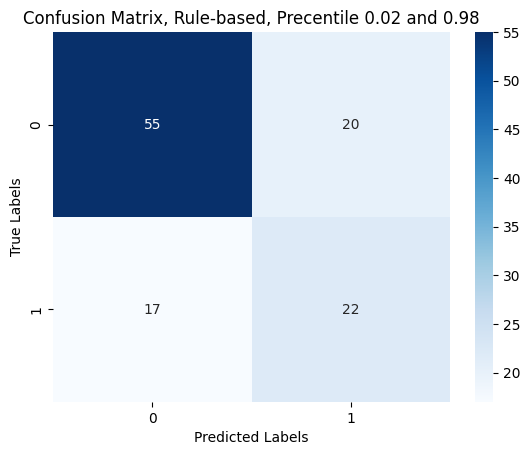

In [97]:
"""A rule-based classifier which follows the following form:
If [cell size is abnormal]:
or [cell shape is abnormal]
or [cell texture is abnormal]
or [cell homogeneity is abnormal], 
then: diagnosis is malignant, 
otherwise: diagnosis is benign.

There are 3 measurements for each feature 0,1,2
"""

# concating the 3 measurements for each feature

# data_long = pd.wide_to_long(data, stubnames=features, i='id',
#                           j='sample', sep='_').reset_index()

# print(data_long.shape)


train, test = train_test_split(data, test_size=0.2, random_state=21)
test['malignant_pred'] = 0

threshold = 1.9

for column in train.columns[2:]:
    # creating a rule for the classifier
    """
    USING A SIMPLE BOTTOM 5 AND TOP 5 PERCENTILE THE ACCURACY IS 0.5741066198008201 (data long)
    bottom_10 = data_long[column].quantile(0.05) 
    top_10 = data_long[column].quantile(0.95)
    
    below = data_long[column] < bottom_10
    above = data_long[column] > top_10
    abnormal_condition = (below + above) > 0
    """

    # bottom_10 = train[column].quantile(0.02) 
    # top_10 = train[column].quantile(0.98)
    
    # below = test[column] < bottom_10
    # above = test[column] > top_10
    # abnormal_condition = (below + above) > 0

    z = (test[column] - train[column].mean()) / train[column].std()
    abnormal_condition = z.abs() > threshold

    # classifying 
    test.loc[abnormal_condition, 'malignant_pred'] = 1

print("ACCURACY OF THE MODEL:", metrics.accuracy_score(test['malignant'], test['malignant_pred']))


# confusion matrix
cm = metrics.confusion_matrix(test['malignant'], test['malignant_pred'])
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix, Rule-based, Precentile 0.02 and 0.98")

plt.show()


In [68]:
data_long.head()

,,malignant,radius,texture,perimeter,area,smoothness,compactness,concavity,concave points,symmetry,fractal dimension,malignant_pred
id,sample,,,,,,,,,,,,
842302,0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,0
842517,0,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,1
84300903,0,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0
84348301,0,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0
84358402,0,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0


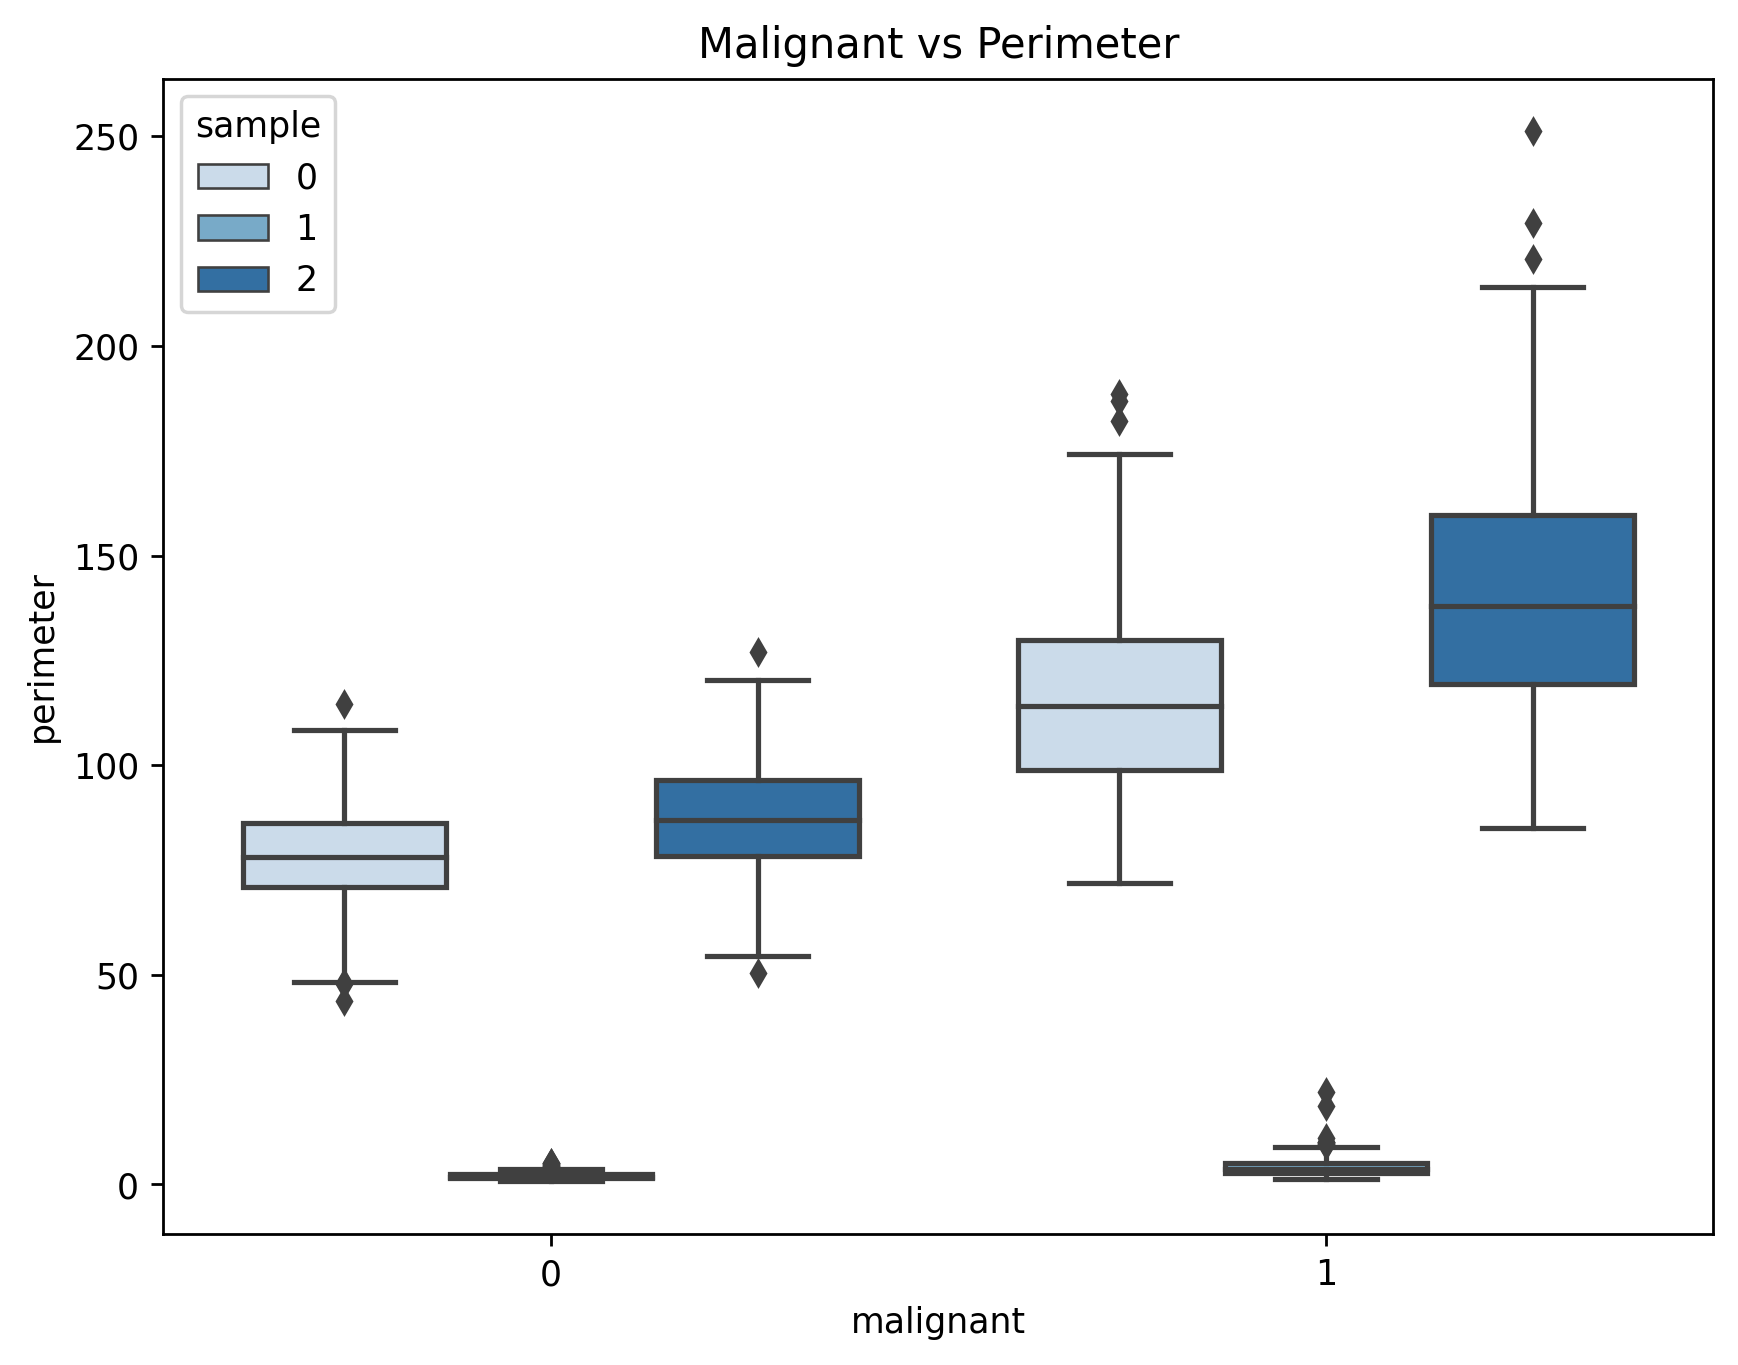

In [75]:
plt.figure(figsize=(8, 6), dpi=250)
sns.boxplot(x='malignant', y='perimeter', hue='sample', data=data_long, palette='Blues')
plt.title('Malignant vs Perimeter')
plt.show()

### Random Forest Classifier 

In [9]:
#WITH ORIGINAL DATA
clf = RandomForestClassifier(n_estimators = 300)  
 
clf.fit(X_train, y_train)
 
y_pred = clf.predict(X_test)
 
print("ACCURACY OF THE MODEL:", metrics.accuracy_score(y_test, y_pred))

ACCURACY OF THE MODEL: 0.9736842105263158


In [10]:
# WITH LONG DATA
X = data_long.drop('malignant', axis=1)
y = data_long['malignant']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

clf = RandomForestClassifier(n_estimators = 300)  
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

df = X_test.copy()
df['y_pred'] = y_pred 
def aggregate_predictions(preds):
    if len(preds) == 3:
        return preds.mode().iloc[0]
    elif len(preds) == 2:
        return preds.iloc[0]
    else:
        return preds.iloc[0]

grouped_preds = df.groupby(level=0)['y_pred'].apply(aggregate_predictions)

df['y_true'] = y_test  # assuming y_test order matches df
grouped_true = df.groupby(level=0)['y_true'].first()

# Now compare grouped predictions to grouped true labels
accuracy = metrics.accuracy_score(grouped_true, grouped_preds)
print("Grouped Accuracy of the Model:", accuracy)
 
print("ACCURACY OF THE MODEL:", metrics.accuracy_score(y_test, y_pred))

Grouped Accuracy of the Model: 0.9365671641791045
ACCURACY OF THE MODEL: 0.9327485380116959


### Own Classifier

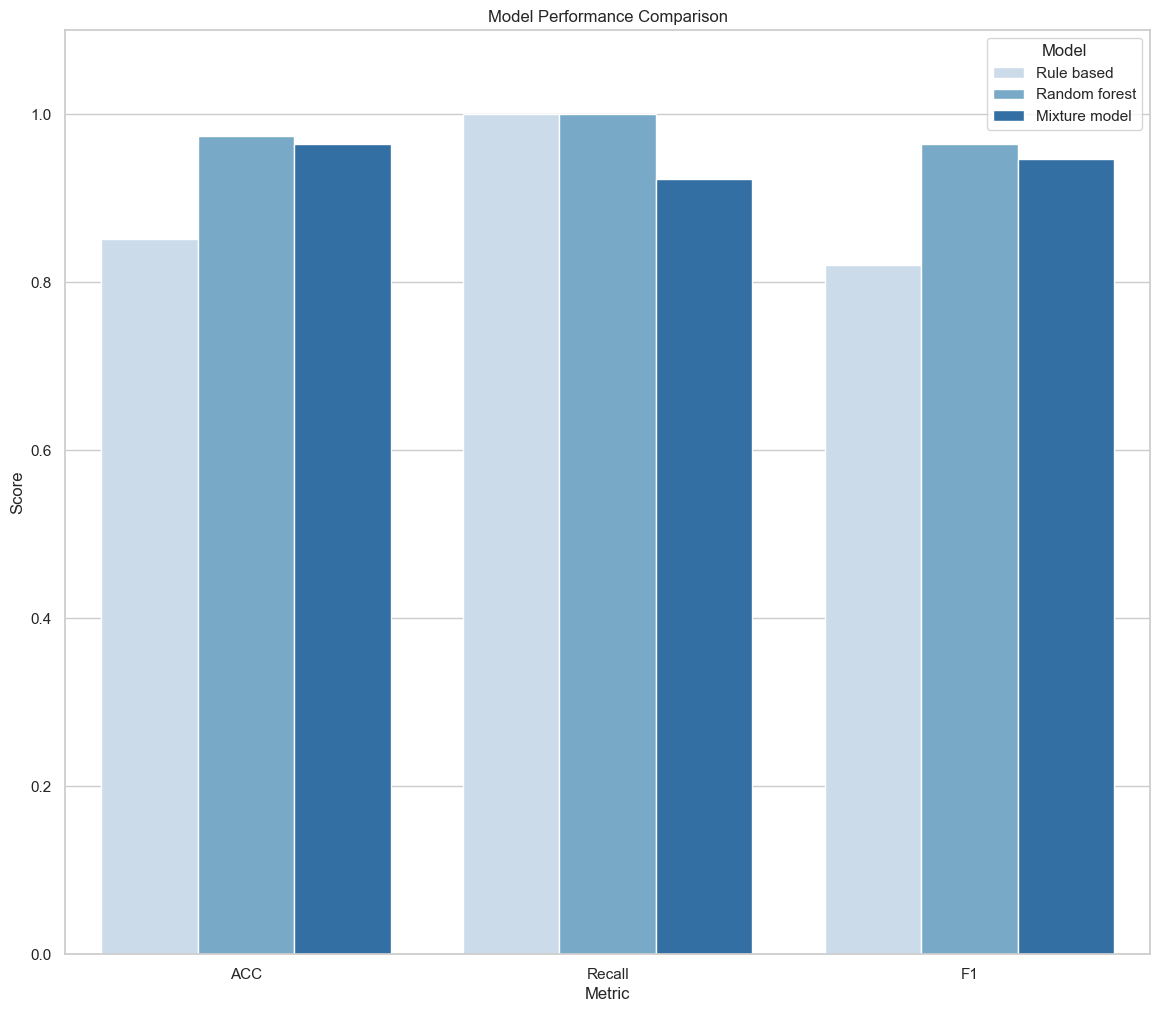

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the data
data = [
    {"Model": "Rule based", "Metric": "ACC", "Score": 0.851},
    {"Model": "Rule based", "Metric": "Recall", "Score": 1.0},
    {"Model": "Rule based", "Metric": "F1", "Score": 0.8211},
    {"Model": "Random forest", "Metric": "ACC", "Score": 0.974},
    {"Model": "Random forest", "Metric": "Recall", "Score": 1.0},
    {"Model": "Random forest", "Metric": "F1", "Score": 0.964},
    {"Model": "Mixture model", "Metric": "ACC", "Score": 0.965},
    {"Model": "Mixture model", "Metric": "Recall", "Score": 0.923},
    {"Model": "Mixture model", "Metric": "F1", "Score": 0.947}
]

# Convert to DataFrame
df = pd.DataFrame(data)

# Set the Seaborn theme
sns.set_theme(style="whitegrid")

# Create a grouped bar plot with a blue palette
plt.figure(figsize=(14, 12))
ax = sns.barplot(
    x="Metric", 
    y="Score", 
    hue="Model", 
    data=df, 
    palette=sns.color_palette("Blues", n_colors=3)
)

# Set y-axis limit for clarity
ax.set(ylim=(0, 1.1))
plt.title("Model Performance Comparison")
plt.show()
